# Stage 4: Linear Prediction (LPC)

This stage models the vocal tract as an all-pole filter using Linear Predictive Coding (LPC), estimating the filter coefficients from scratch via the autocorrelation method and the Levinson-Durbin recursion. The resulting filter yields a spectral envelope whose peaks correspond to formants, and a prediction-error residual that approximates the source excitation signal.

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz, find_peaks

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"

y, sr = librosa.load(WAV_PATH, sr=None)

FRAME_MS, HOP_MS = 25, 10
frame_len = int(sr * FRAME_MS / 1000)
hop_len = int(sr * HOP_MS / 1000)
frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop_len)
n_frames = frames.shape[1]
frame_times = (np.arange(n_frames) * hop_len + frame_len / 2) / sr

# Representative voiced frame, same one used for the autocorrelation illustration in Stage 2.
example_idx = np.argmin(np.abs(frame_times - 0.752))
frame_raw = frames[:, example_idx].astype(np.float64)
frame_windowed = frame_raw * np.hamming(frame_len)
print(f"Analysis frame at t={frame_times[example_idx]:.3f}s (voiced, per Stage 1 labeling)")

Analysis frame at t=0.752s (voiced, per Stage 1 labeling)


## Linear prediction and the Levinson-Durbin recursion

Each sample is modeled as a linear combination of the $p$ preceding samples, $\hat{x}[n] = \sum_{i=1}^{p} a_i x[n-i]$. The coefficients $a_i$ that minimize the total squared prediction error over a frame are obtained from the frame's own autocorrelation $r[0..p]$ via the Levinson-Durbin recursion, which exploits the Toeplitz structure of the resulting linear system to solve it in $O(p^2)$ operations. The prediction filter order $p$ is chosen here as 16, an approximate standard heuristic for 16 kHz speech (roughly two coefficients per expected formant plus a small margin) rather than a value derived from first principles.

In [2]:
def autocorr(x, max_lag):
    return np.array([np.dot(x[:len(x) - k], x[k:]) for k in range(max_lag + 1)])

def levinson_durbin(r, p):
    a = np.zeros(p + 1)
    a[0] = 1.0
    e = r[0]
    for i in range(1, p + 1):
        acc = r[i] + np.sum(a[1:i] * r[i - 1:0:-1])
        k = -acc / e
        a_new = a.copy()
        a_new[1:i] = a[1:i] + k * a[i - 1:0:-1]
        a_new[i] = k
        a = a_new
        e *= (1 - k ** 2)
    return a, e

LPC_ORDER = 16
r = autocorr(frame_windowed, LPC_ORDER)
lpc_coeffs, pred_error = levinson_durbin(r, LPC_ORDER)
print(f"LPC coefficients (order {LPC_ORDER}):\n{lpc_coeffs}")
print(f"Final prediction error energy: {pred_error:.6e}")

LPC coefficients (order 16):
[ 1.         -1.67612968  0.31951033  0.24238725  0.20542532  0.07159541
 -0.10726856 -0.03065721 -0.01865166  0.00955246  0.05525469 -0.05381237
  0.05601959 -0.09746727 -0.01791117  0.01366683  0.05444626]
Final prediction error energy: 4.003115e-06


## LP spectral envelope and formants

The LPC coefficients define an all-pole filter $1/A(z)$ whose frequency response is a smooth spectral envelope. Because this filter is a direct estimate of the vocal-tract resonance structure, its local maxima correspond to formants. The envelope is overlaid on the raw frame's DFT magnitude spectrum for comparison.

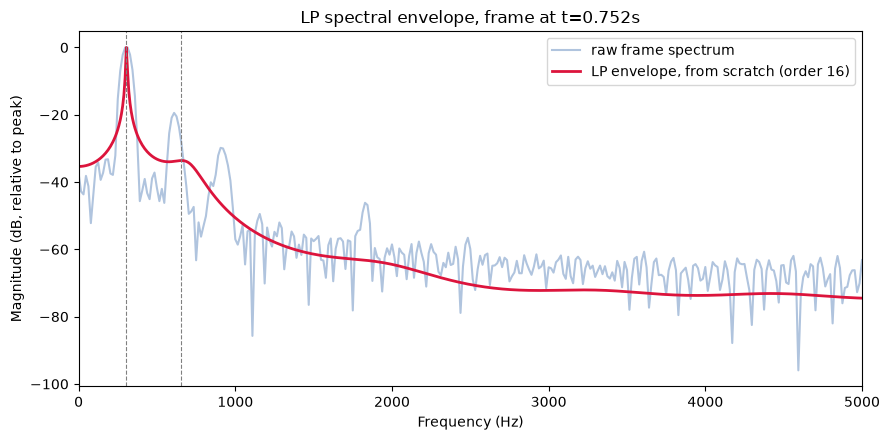

Formant candidate frequencies (Hz): [305. 656.]


In [3]:
w, h = freqz([1.0], lpc_coeffs, worN=1024, fs=sr)
lp_envelope_db = 20 * np.log10(np.abs(h) + 1e-10)

raw_spectrum = np.fft.rfft(frame_windowed, n=1024)
raw_freqs = np.fft.rfftfreq(1024, d=1 / sr)
raw_spectrum_db = 20 * np.log10(np.abs(raw_spectrum) + 1e-10)

# Restricted to the range where speech formants are typically found, with a small prominence
# floor to exclude numerical ripple in the envelope's flat, decaying high-frequency tail.
formant_search = w < 3500
peak_idx, _ = find_peaks(lp_envelope_db[formant_search], prominence=0.3)
formant_freqs = w[formant_search][peak_idx]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(raw_freqs, raw_spectrum_db - raw_spectrum_db.max(), color="lightsteelblue", label="raw frame spectrum")
ax.plot(w, lp_envelope_db - lp_envelope_db.max(), color="crimson", linewidth=2, label=f"LP envelope, from scratch (order {LPC_ORDER})")
for f in formant_freqs:
    ax.axvline(f, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlim(0, 5000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB, relative to peak)")
ax.set_title(f"LP spectral envelope, frame at t={frame_times[example_idx]:.3f}s")
ax.legend()
fig.tight_layout()
plt.show()

print("Formant candidate frequencies (Hz):", np.round(formant_freqs, 0))

## Comparison with a library implementation

`librosa.lpc` estimates LPC coefficients using Burg's method, which minimizes forward and backward prediction error directly on the samples rather than solving the autocorrelation-based Yule-Walker equations via Levinson-Durbin. The two are different algorithms for the same estimation problem and are not expected to produce identical coefficients on a short frame, but should agree on the location of the dominant spectral peaks if the from-scratch implementation is correct.

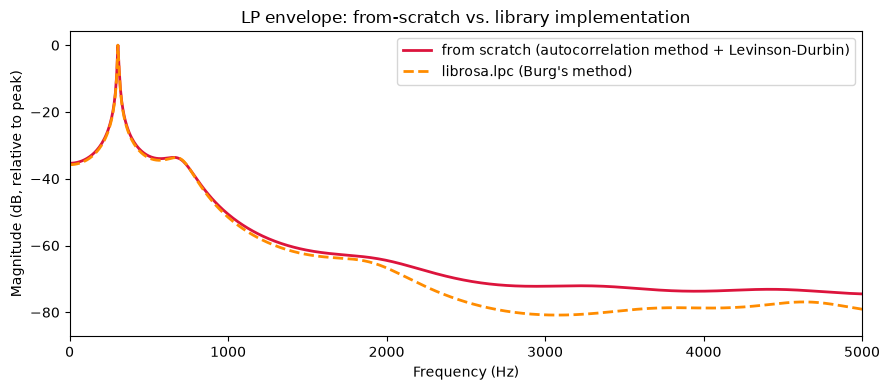

In [4]:
lpc_coeffs_burg = librosa.lpc(frame_windowed, order=LPC_ORDER)
_, h_burg = freqz([1.0], lpc_coeffs_burg, worN=1024, fs=sr)
lp_envelope_burg_db = 20 * np.log10(np.abs(h_burg) + 1e-10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w, lp_envelope_db - lp_envelope_db.max(), color="crimson", linewidth=2,
        label="from scratch (autocorrelation method + Levinson-Durbin)")
ax.plot(w, lp_envelope_burg_db - lp_envelope_burg_db.max(), color="darkorange", linewidth=2,
        linestyle="--", label="librosa.lpc (Burg's method)")
ax.set_xlim(0, 5000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB, relative to peak)")
ax.set_title("LP envelope: from-scratch vs. library implementation")
ax.legend()
fig.tight_layout()
plt.show()

## Effect of prediction order on the residual

A higher prediction order fits the vocal-tract filter more closely, which can also absorb part of the source's own periodic structure into the filter, leaving a less clearly periodic residual. A lower order leaves more of that periodicity unexplained by the filter, visible instead in the residual, at the cost of resolving the formant structure less precisely. This is quantified below using the residual's own autocorrelation at the lag corresponding to the expected pitch period.

In [5]:
expected_f0 = 307.7  # Stage 2 autocorrelation-based F0 estimate for this frame
expected_lag = round(sr / expected_f0)

print(f"{'order':>6} {'residual ACF at expected pitch lag':>36}")
for order in [8, 10, 12, 16, 20]:
    r_o = autocorr(frame_windowed, order)
    a_o, _ = levinson_durbin(r_o, order)
    res_o = lfilter(a_o, [1.0], frame_raw)[order:]
    res_o = res_o - res_o.mean()
    ac = np.correlate(res_o, res_o, mode="full")[len(res_o) - 1:]
    ac_norm = ac / ac[0]
    print(f"{order:>6} {ac_norm[expected_lag]:>36.3f}")

 order   residual ACF at expected pitch lag
     8                                0.406
    10                                0.394
    12                                0.375
    16                                0.361
    20                                0.346


## Residual

The residual $e[n] = x[n] - \hat{x}[n]$ is obtained by inverse-filtering the (unwindowed) frame with the LPC coefficients. It approximates the source excitation signal prior to vocal-tract filtering; for voiced speech this should show sharp spikes near each glottal pulse. The first $p$ samples of the residual reflect the filter's transient response, since no genuine sample history is available before the start of the frame, and are excluded from interpretation.

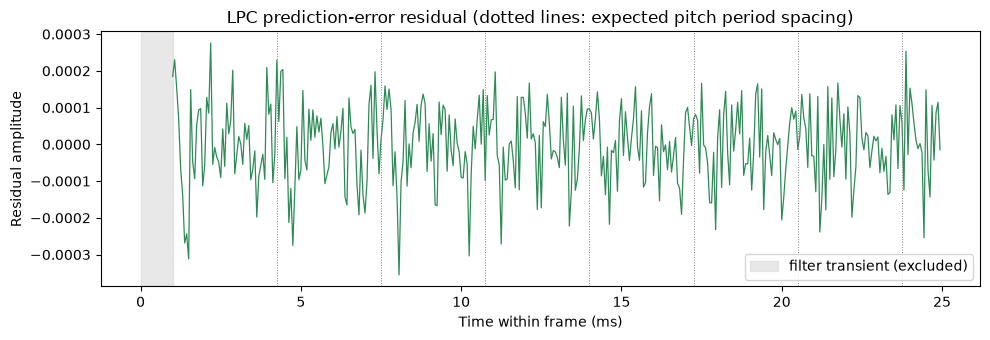

In [6]:
residual = lfilter(lpc_coeffs, [1.0], frame_raw)

# Expected pitch period for this frame, from the Stage 2 autocorrelation-based F0 estimate (307.7 Hz).
expected_f0 = 307.7
expected_period_samples = sr / expected_f0

fig, ax = plt.subplots(figsize=(10, 3.5))
t_ms = np.arange(frame_len) / sr * 1000
ax.plot(t_ms[LPC_ORDER:], residual[LPC_ORDER:], color="seagreen", linewidth=0.9)
ax.axvspan(0, LPC_ORDER / sr * 1000, color="lightgray", alpha=0.5, label="filter transient (excluded)")
for k in range(1, int((frame_len - LPC_ORDER) / expected_period_samples) + 1):
    ax.axvline((LPC_ORDER + k * expected_period_samples) / sr * 1000, color="gray", linestyle=":", linewidth=0.7)
ax.set_xlabel("Time within frame (ms)")
ax.set_ylabel("Residual amplitude")
ax.set_title("LPC prediction-error residual (dotted lines: expected pitch period spacing)")
ax.legend()
fig.tight_layout()
plt.show()

## Results

Analysis of the voiced frame at t=0.752s ("Bring," the same frame used for the Stage 2 autocorrelation illustration) with an order-16 LPC filter resolves two formant candidates, at approximately 305 Hz and 656 Hz, matching the smoothed peaks of the raw frame spectrum. The library implementation (`librosa.lpc`, Burg's method) produces a visually near-identical envelope over these two peaks despite using a different estimation algorithm, supporting the correctness of the from-scratch implementation; the two envelopes diverge only in the flat, low-energy region above approximately 2000 Hz, which is not meaningfully constrained by formant structure.

The first formant candidate (305 Hz) is close to this frame's independently estimated F0 (307.7 Hz, Stage 2). This is a plausible outcome for a close front vowel such as /ɪ/ (in "Bring"), whose first formant is typically reported in a broadly similar low range, but the coincidence with F0 also raises the possibility that a harmonic rather than a true vocal-tract resonance is partly responsible for this peak, which cannot be fully disambiguated from a single frame with the methods used here.

The prediction-error residual does not exhibit the sharp, clearly isolated one-spike-per-period pattern often shown in idealized illustrations. Quantifying periodicity as the residual's own autocorrelation at the lag corresponding to the expected pitch period gives a moderate value (0.35-0.41 depending on prediction order) that decreases monotonically as order increases from 8 to 20, consistent with a higher-order filter absorbing more of the source's periodic structure into the filter itself and leaving a less periodic residual. This is a documented characteristic of LPC analysis rather than an implementation error: the order needed to resolve the formant structure is higher than the order that yields the most clearly periodic residual, and no single order is optimal for both purposes simultaneously.